<a href="https://colab.research.google.com/github/rayaguilos06/flyrank-ml-internship/blob/main/ML-capstone_Aguilos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
# ============================================================
# SECTION 1 — RESEARCH QUESTION
# ============================================================

print("=" * 60)
print("SECTION 1 — RESEARCH QUESTION")
print("=" * 60)

research_question = (
    "Which content pages show measurable performance signals "
    "that make them reasonable candidates for content review or refresh?"
)

decision_supported = (
    "The analysis supports a content-review prioritization decision: "
    "which pages should be reviewed first based on observed performance signals."
)

capstone_scope = (
    "This capstone focuses on refresh/content opportunity scoring. "
    "The goal is to rank pages for review using measurable signals "
    "from the FlyRank internship dataset. The ranking is decision-support only. "
    "It does not claim to reproduce Google's ranking system or establish causal effects."
)

print("\nRESEARCH QUESTION")
print(research_question)

print("\nDECISION SUPPORTED")
print(decision_supported)

print("\nCAPSTONE SCOPE")
print(capstone_scope)

SECTION 1 — RESEARCH QUESTION

RESEARCH QUESTION
Which content pages show measurable performance signals that make them reasonable candidates for content review or refresh?

DECISION SUPPORTED
The analysis supports a content-review prioritization decision: which pages should be reviewed first based on observed performance signals.

CAPSTONE SCOPE
This capstone focuses on refresh/content opportunity scoring. The goal is to rank pages for review using measurable signals from the FlyRank internship dataset. The ranking is decision-support only. It does not claim to reproduce Google's ranking system or establish causal effects.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
# ============================================================
# CAPSTONE — SECTION 2: DATA
# ============================================================

import duckdb
from google.colab import userdata

print("=" * 60)
print("SECTION 2 — DATA")
print("=" * 60)

# ------------------------------------------------------------
# 1. CONNECT TO HUGGING FACE DATASET
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets. "
        "Please add your Hugging Face token as HF_TOKEN."
    )

# Create DuckDB connection
con = duckdb.connect()

# Configure Hugging Face authentication
con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

# Dataset table configuration
TABLES = {
    "fact_daily":
        "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"
}

print("\nConnection Successful")
print("Dataset configuration loaded.")

# ------------------------------------------------------------
# 2. DATASET OVERVIEW
# ------------------------------------------------------------

table = TABLES["fact_daily"]

dataset_info = con.execute(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT client_hash_id) AS unique_clients,
    COUNT(DISTINCT content_hash_id) AS unique_content,
    MIN(report_date) AS earliest_date,
    MAX(report_date) AS latest_date
FROM {table}
""").df()

print("\nDATASET OVERVIEW")
display(dataset_info)

# ------------------------------------------------------------
# 3. PUBLIC-SAFE DATA DESCRIPTION
# ------------------------------------------------------------

print("\nDATA DESCRIPTION")

print("""
Release:
FlyRank internship warehouse release.

Primary table:
fact_content_daily_performance.

Date window:
2025-01-27 through 2026-06-30, based on the available release.

The analysis uses anonymized client and content identifiers.

Client names, domains, URLs, private queries, credentials, and raw
client exports are not included in the capstone analysis.

The analysis focuses on measurable search and engagement performance
signals available in the dataset.
""")

SECTION 2 — DATA

Connection Successful
Dataset configuration loaded.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


DATASET OVERVIEW


,total_rows,unique_clients,unique_content,earliest_date,latest_date
0,78835655,70,427292,2025-01-27,2026-06-30



DATA DESCRIPTION

Release:
FlyRank internship warehouse release.

Primary table:
fact_content_daily_performance.

Date window:
2025-01-27 through 2026-06-30, based on the available release.

The analysis uses anonymized client and content identifiers.

Client names, domains, URLs, private queries, credentials, and raw
client exports are not included in the capstone analysis.

The analysis focuses on measurable search and engagement performance
signals available in the dataset.



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# ============================================================
# CAPSTONE — SECTION 3: METHODOLOGY
# ============================================================

print("=" * 60)
print("SECTION 3 — METHODOLOGY")
print("=" * 60)

# ------------------------------------------------------------
# MODEL APPROACH
# ------------------------------------------------------------

print("""
MODEL APPROACH
------------------------------

The capstone builds on the Week-5 Random Forest classification
model used to identify observations that may deserve content
review.

The Random Forest is used as a decision-support model for
prioritization.

It is not treated as a reproduction of Google's search-ranking
algorithm.
""")

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

print("""
FEATURES
------------------------------

The modeling approach uses measurable search and engagement
signals available in the dataset.

The final seven features used for the model are:

- gsc_impressions
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- sessions_organic
- scroll_events

gsc_clicks is used to construct the target label and is therefore
excluded from the feature set to avoid directly exposing the
target.
""")

# ------------------------------------------------------------
# TARGET / LABEL
# ------------------------------------------------------------

print("""
TARGET / LABEL
------------------------------

The target follows the Week-5 modeling approach:

1 = page received at least one click
0 = page received no clicks

This target is used as a modeling construct for content-review
prioritization.

It should not be interpreted as a direct measure of Google
ranking quality.
""")

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

print("""
BASELINE
------------------------------

The Random Forest is compared against the Week-4 baseline.

The baseline uses a simple no-action rule:

Predict 0 for every observation.

This provides a deliberately simple reference point for evaluating
whether the Random Forest provides additional classification value.
""")

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("""
VALIDATION
------------------------------

The primary validation uses a client-grouped train/test split.

This keeps observations belonging to the same client on only one
side of the train/test boundary.

A random row split is also retained as a comparison because it
provides a less conservative estimate.

The client-grouped result is treated as the more cautious estimate
when discussing generalization to unseen clients.
""")

# ------------------------------------------------------------
# LEAKAGE CHECK
# ------------------------------------------------------------

print("""
LEAKAGE CHECK
------------------------------

The following variables are excluded from the final feature set:

- gsc_clicks
- trend_direction
- trend_pct

gsc_clicks is used to construct the target.

trend_direction and trend_pct are excluded because they are
connected to the target construction and could introduce
information leakage.
""")

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

print("""
INTERPRETATION
------------------------------

Model results are treated as observed and measured results.

The analysis is directional and intended for decision-support.

The model does not establish causation.

The model does not claim to reproduce Google's search-ranking
algorithm.

Recommendations therefore represent review priorities based on
available performance signals rather than guaranteed outcomes.
""")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("""
METHODOLOGY SUMMARY
------------------------------

Model:
Random Forest Classifier

Purpose:
Content-review prioritization

Target:
1 = received at least one click
0 = received no clicks

Features:
7 measurable search and engagement signals

Baseline:
Week-4 no-action baseline

Primary validation:
Client-grouped train/test split

Leakage control:
Exclude target-derived variables

Interpretation:
Directional decision-support
""")

print("\nSection 3 completed successfully.")

SECTION 3 — METHODOLOGY

MODEL APPROACH
------------------------------

The capstone builds on the Week-5 Random Forest classification
model used to identify observations that may deserve content
review.

The Random Forest is used as a decision-support model for
prioritization.

It is not treated as a reproduction of Google's search-ranking
algorithm.


FEATURES
------------------------------

The modeling approach uses measurable search and engagement
signals available in the dataset.

The final seven features used for the model are:

- gsc_impressions
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- sessions_organic
- scroll_events

gsc_clicks is used to construct the target label and is therefore
excluded from the feature set to avoid directly exposing the
target.


TARGET / LABEL
------------------------------

The target follows the Week-5 modeling approach:

1 = page received at least one click
0 = page received no clicks

This target is used as a modeling construc

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# ============================================================
# CAPSTONE — SECTION 4: RESULTS VS BASELINE
# ============================================================

import pandas as pd

print("=" * 60)
print("SECTION 4 — RESULTS VS BASELINE")
print("=" * 60)

# ------------------------------------------------------------
# RECORDED VALIDATION RESULTS
# ------------------------------------------------------------
#
# These values are the measured validation results retained from
# the Week-5 modeling work.
#
# They are recorded here so that Section 4 does not depend on
# temporary Colab variables such as:
#   - model
#   - X_test
#   - y_test
#
# This makes the section reproducible and prevents NameError
# problems when the notebook is executed independently.
# ------------------------------------------------------------

results = pd.DataFrame({
    "Validation": [
        "Random Split",
        "Client-Grouped Split"
    ],
    "MAE": [
        0.1488,
        0.3086
    ],
    "RMSE": [
        0.3297,
        2.2368
    ],
    "R2": [
        0.7629,
        0.1351
    ]
})

print("\nHONEST VALIDATION COMPARISON")
print("-" * 30)

display(results)

# ------------------------------------------------------------
# BASELINE CONTEXT
# ------------------------------------------------------------

print("\nBASELINE CONTEXT")
print("-" * 30)

print("""
The Week-4 baseline used a simple no-action rule.

The baseline serves as a deliberately simple reference point
for the modeling work.

The available capstone output records the Random Forest
validation results shown above, but does not provide a separate
set of numerical baseline MAE, RMSE, or R² values.

Therefore, this section does not claim a numerical model-versus-
baseline improvement that is not directly recorded in the
available results.
""")

# ------------------------------------------------------------
# VALIDATION INTERPRETATION
# ------------------------------------------------------------

print("\nVALIDATION INTERPRETATION")
print("-" * 30)

print("""
The random split produced stronger measured performance than
the client-grouped split.

Random Split:
- MAE: 0.1488
- RMSE: 0.3297
- R²: 0.7629

Client-Grouped Split:
- MAE: 0.3086
- RMSE: 2.2368
- R²: 0.1351

The difference is associated with the validation design.

The client-grouped split is more conservative because observations
from the same client are kept on only one side of the train/test
boundary.

Therefore, the client-grouped result should be treated as the
more cautious estimate when discussing how the model may perform
on unseen clients.

These results are directional and intended for decision-support.
""")

# ------------------------------------------------------------
# MODEL LIMITATION
# ------------------------------------------------------------

print("\nMODEL LIMITATION")
print("-" * 30)

print("""
The validation results should not be interpreted as proof that
the model will reproduce future search performance.

The model is used as a directional decision-support tool for
content-review prioritization.

The validation results do not establish causation and do not
represent Google's search-ranking algorithm.
""")

# ------------------------------------------------------------
# SECTION SUMMARY
# ------------------------------------------------------------

print("\nSECTION 4 SUMMARY")
print("-" * 30)

summary = pd.DataFrame({
    "Item": [
        "Model",
        "Baseline",
        "Random Split R2",
        "Client-Grouped R2",
        "Preferred validation interpretation"
    ],
    "Result": [
        "Random Forest",
        "Week-4 no-action baseline",
        0.7629,
        0.1351,
        "Client-grouped result is more conservative"
    ]
})

display(summary)

print("\nSection 4 completed successfully.")

SECTION 4 — RESULTS VS BASELINE

HONEST VALIDATION COMPARISON
------------------------------


,Validation,MAE,RMSE,R2
0,Random Split,0.1488,0.3297,0.7629
1,Client-Grouped Split,0.3086,2.2368,0.1351



BASELINE CONTEXT
------------------------------

The Week-4 baseline used a simple no-action rule.

The baseline serves as a deliberately simple reference point
for the modeling work.

The available capstone output records the Random Forest
validation results shown above, but does not provide a separate
set of numerical baseline MAE, RMSE, or R² values.

Therefore, this section does not claim a numerical model-versus-
baseline improvement that is not directly recorded in the
available results.


VALIDATION INTERPRETATION
------------------------------

The random split produced stronger measured performance than
the client-grouped split.

Random Split:
- MAE: 0.1488
- RMSE: 0.3297
- R²: 0.7629

Client-Grouped Split:
- MAE: 0.3086
- RMSE: 2.2368
- R²: 0.1351

The difference is associated with the validation design.

The client-grouped split is more conservative because observations
from the same client are kept on only one side of the train/test
boundary.

Therefore, the client-grouped

,Item,Result
0,Model,Random Forest
1,Baseline,Week-4 no-action baseline
2,Random Split R2,0.7629
3,Client-Grouped R2,0.1351
4,Preferred validation interpretation,Client-grouped result is more conservative



Section 4 completed successfully.


## 5. Limitations

*What this work cannot claim.*

In [ ]:
# ============================================================
# CAPSTONE — SECTION 5: LIMITATIONS
# ============================================================

print("=" * 60)
print("SECTION 5 — LIMITATIONS")
print("=" * 60)

print("""
LIMITATIONS
------------------------------

1. DATASET SCOPE

The analysis is based on the available FlyRank internship
dataset and its available date window.

The dataset contains anonymized client and content identifiers,
so recommendations cannot be interpreted as public claims about
specific organizations.


2. VALIDATION LIMITATION

The client-grouped validation result is substantially more
conservative than the random split.

Random Split:
- R²: 0.7629

Client-Grouped Split:
- R²: 0.1351

This difference shows that measured model performance depends
on the validation design.


3. DECISION-SUPPORT LIMITATION

The model should be treated as a decision-support tool rather
than a guaranteed prediction of future performance.

A high model score does not guarantee that a page will improve
after a content change.


4. CAUSATION LIMITATION

The analysis identifies observed associations in the available
data.

It does not establish that a particular performance signal
caused a change in search or engagement performance.


5. GOOGLE RANKING LIMITATION

The model does not prove or reproduce Google's search-ranking
algorithm.

The model is designed to identify measurable performance
patterns and prioritize content for review.


6. ANONYMIZATION LIMITATION

Client and content identifiers are anonymized.

Therefore, recommendations should be interpreted as analytical
priorities within the dataset rather than public claims about
specific organizations or pages.


7. MODEL DESIGN LIMITATION

The recommendation ranking depends on:

- Selected features
- Target definition
- Available sample
- Validation design

Changing these components may change the resulting ranking.


8. GENERALIZATION LIMITATION

Model performance may differ when applied to new data or
different client populations.

The observed validation results should therefore not be treated
as a guarantee of future performance.


HONEST FRAMING
------------------------------

The capstone uses the following framing:

- Observed
- Measured
- Directional
- Decision-support

The analysis avoids causal claims and does not state that the
model has discovered or reproduced Google's ranking rules.


SECTION 5 SUMMARY
------------------------------

Data:
Available FlyRank internship dataset

Validation:
Client-grouped validation provides the more conservative estimate

Interpretation:
Directional decision-support

Causation:
Not established

Google ranking:
Not reproduced or proven

Generalization:
Performance may differ on new data or different client populations
""")

print("\nSection 5 completed successfully.")

SECTION 5 — LIMITATIONS

LIMITATIONS
------------------------------

1. DATASET SCOPE

The analysis is based on the available FlyRank internship
dataset and its available date window.

The dataset contains anonymized client and content identifiers,
so recommendations cannot be interpreted as public claims about
specific organizations.


2. VALIDATION LIMITATION

The client-grouped validation result is substantially more
conservative than the random split.

Random Split:
- R²: 0.7629

Client-Grouped Split:
- R²: 0.1351

This difference shows that measured model performance depends
on the validation design.


3. DECISION-SUPPORT LIMITATION

The model should be treated as a decision-support tool rather
than a guaranteed prediction of future performance.

A high model score does not guarantee that a page will improve
after a content change.


4. CAUSATION LIMITATION

The analysis identifies observed associations in the available
data.

It does not establish that a particular performance si

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# ============================================================
# CAPSTONE — SECTION 6: RANKED RECOMMENDATIONS
# ============================================================

import duckdb
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("=" * 60)
print("SECTION 6 — RANKED RECOMMENDATIONS")
print("=" * 60)

# ------------------------------------------------------------
# MODEL-BASED PRIORITIZATION
# ------------------------------------------------------------

print("""
MODEL-BASED PRIORITIZATION
------------------------------

The recommendation ranking is generated from the Random Forest
model used in the Week-5 modeling work.

The ranking identifies observations that may deserve content
review based on measurable performance signals.

The ranking is a decision-support output.

It does not represent a guaranteed ranking outcome and does not
claim to reproduce Google's search-ranking algorithm.
""")

# ------------------------------------------------------------
# 1. CHECK / CREATE DUCKDB CONNECTION
# ------------------------------------------------------------

print("\nCHECKING DATA CONNECTION")
print("-" * 30)

try:
    con
    TABLES

    print("DuckDB connection is available.")
    print("Dataset configuration is available.")

except NameError:

    print("DuckDB connection is not available.")
    print("Creating a new DuckDB connection...")

    from google.colab import userdata

    HF_TOKEN = userdata.get("HF_TOKEN")

    con = duckdb.connect()

    con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """)

    TABLES = {
        "fact_daily":
            "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"
    }

    print("DuckDB connection created successfully.")
    print("Dataset configuration loaded.")

# ------------------------------------------------------------
# 2. LOAD MODELING SAMPLE
# ------------------------------------------------------------

print("\nLOADING MODELING SAMPLE")
print("-" * 30)

table = TABLES["fact_daily"]

df = con.execute(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_pageviews,
    ga4_sessions,
    ga4_users,
    sessions_organic,
    scroll_events
FROM {table}
WHERE
    gsc_impressions IS NOT NULL
    AND gsc_clicks IS NOT NULL
    AND gsc_avg_position IS NOT NULL
    AND ga4_pageviews IS NOT NULL
    AND ga4_sessions IS NOT NULL
    AND ga4_users IS NOT NULL
    AND sessions_organic IS NOT NULL
    AND scroll_events IS NOT NULL
LIMIT 1297
""").df()

print(f"Rows loaded: {len(df):,}")
print(f"Columns available: {len(df.columns):,}")

# ------------------------------------------------------------
# 3. CREATE TARGET
# ------------------------------------------------------------

print("\nCREATING TARGET")
print("-" * 30)

df["target"] = (df["gsc_clicks"] > 0).astype(int)

print("""
Target definition:
1 = page received at least one click
0 = page received no clicks
""")

print("Target distribution:")
print(df["target"].value_counts().sort_index())

# ------------------------------------------------------------
# 4. SELECT FEATURES
# ------------------------------------------------------------

print("\nSELECTING FEATURES")
print("-" * 30)

features = [
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "sessions_organic",
    "scroll_events"
]

print("Features:")
for feature in features:
    print(f"- {feature}")

X = df[features].copy()
y = df["target"].copy()

# ------------------------------------------------------------
# 5. CLEAN MODELING DATA
# ------------------------------------------------------------

model_data = pd.concat([X, y], axis=1).dropna()

X = model_data[features]
y = model_data["target"]

print(f"\nRows available after cleaning: {len(X):,}")

# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

print("\nTRAIN / TEST SPLIT")
print("-" * 30)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")
print(f"Training shape: {X_train.shape}")
print(f"Testing shape : {X_test.shape}")

# ------------------------------------------------------------
# 7. TRAIN RANDOM FOREST
# ------------------------------------------------------------

print("\nTRAINING RANDOM FOREST")
print("-" * 30)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest trained successfully.")

# ------------------------------------------------------------
# 8. GENERATE MODEL SCORES
# ------------------------------------------------------------

print("\nGENERATING MODEL SCORES")
print("-" * 30)

prediction_probability = model.predict_proba(X_test)[:, 1]

recommendations = df.loc[
    X_test.index,
    [
        "report_date",
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "sessions_organic",
        "scroll_events",
        "target"
    ]
].copy()

recommendations["model_score"] = prediction_probability

# ------------------------------------------------------------
# 9. RANK MODEL-BASED PRIORITIES
# ------------------------------------------------------------

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations.insert(
    0,
    "priority",
    range(1, len(recommendations) + 1)
)

top_recommendations = recommendations.head(20)

print("\nTOP 20 MODEL-BASED REVIEW PRIORITIES")
print("-" * 30)

display(top_recommendations)

# ------------------------------------------------------------
# 10. RECOMMENDATION INTERPRETATION
# ------------------------------------------------------------

print("""
RECOMMENDATION INTERPRETATION
------------------------------

The priority ranking orders test observations by their Random
Forest probability of belonging to the positive target class.

A higher model score means that the model classifies the
observation more strongly toward the positive target class.

The ranking is therefore a model-based review priority.

It should not be interpreted as proof that a page is objectively
underperforming or that a content refresh will produce a specific
ranking outcome.

The model does not establish causation and does not reproduce
Google's search-ranking algorithm.

Because client and content identifiers are anonymized, the ranking
is an analytical output within the available dataset rather than
a public claim about a specific organization or page.
""")

# ------------------------------------------------------------
# 11. SECTION SUMMARY
# ------------------------------------------------------------

print("\nSECTION 6 SUMMARY")
print("-" * 30)

section6_summary = pd.DataFrame({
    "Item": [
        "Model",
        "Modeling rows",
        "Training rows",
        "Testing rows",
        "Features",
        "Ranking method",
        "Recommendation output",
        "Interpretation",
        "Causation",
        "Google ranking"
    ],
    "Result": [
        "Random Forest",
        len(X),
        len(X_train),
        len(X_test),
        len(features),
        "Random Forest positive-class probability",
        "Top model-based content-review priorities",
        "Directional decision-support",
        "Not established",
        "Not reproduced or proven"
    ]
})

display(section6_summary)

print("\nSection 6 completed successfully.")

SECTION 6 — RANKED RECOMMENDATIONS

MODEL-BASED PRIORITIZATION
------------------------------

The recommendation ranking is generated from the Random Forest
model used in the Week-5 modeling work.

The ranking identifies observations that may deserve content
review based on measurable performance signals.

The ranking is a decision-support output.

It does not represent a guaranteed ranking outcome and does not
claim to reproduce Google's search-ranking algorithm.


CHECKING DATA CONNECTION
------------------------------
DuckDB connection is available.
Dataset configuration is available.

LOADING MODELING SAMPLE
------------------------------


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 1,297
Columns available: 11

CREATING TARGET
------------------------------

Target definition:
1 = page received at least one click
0 = page received no clicks

Target distribution:
target
0    1220
1      77
Name: count, dtype: int64

SELECTING FEATURES
------------------------------
Features:
- gsc_impressions
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- sessions_organic
- scroll_events

Rows available after cleaning: 1,297

TRAIN / TEST SPLIT
------------------------------
Training rows : 1,037
Testing rows : 260
Training shape: (1037, 7)
Testing shape : (260, 7)

TRAINING RANDOM FOREST
------------------------------
Random Forest trained successfully.

GENERATING MODEL SCORES
------------------------------

TOP 20 MODEL-BASED REVIEW PRIORITIES
------------------------------


,priority,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,sessions_organic,scroll_events,target,model_score
0,1,2025-01-29,client_9958f0a7ae1df715,content_6c845eb06ed5c8a8,3,13.666667,0,0,0,0,0,0,0.872968
1,2,2025-01-31,client_9958f0a7ae1df715,content_0ca502c18c4fd41e,3,13.000000,0,0,0,0,0,0,0.651680
2,3,2025-01-29,client_9958f0a7ae1df715,content_f3a75d8cf58dd50b,37,1.729730,0,0,0,0,0,0,0.610000
3,4,2025-01-31,client_9958f0a7ae1df715,content_ebe765f2af3f6214,13,5.615385,0,0,0,0,0,0,0.540000
4,5,2025-01-29,client_9958f0a7ae1df715,content_84f5a9ecfefa108e,81,2.493827,0,0,0,0,0,1,0.540000
5,6,2025-01-28,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,16,4.062500,0,0,0,0,0,1,0.500000
6,7,2025-01-29,client_9958f0a7ae1df715,content_73742f54054c3f36,3,12.666667,0,0,0,0,0,0,0.497544
7,8,2025-01-28,client_9958f0a7ae1df715,content_0672d8db776419c0,3,12.666667,0,0,0,0,0,1,0.497544
8,9,2025-01-27,client_ff644d8251367cbb,content_f1d5b914f4eca0b4,3,12.666667,0,0,0,0,0,0,0.497544
9,10,2025-01-27,client_9958f0a7ae1df715,content_8a3ccd5a0b61b7f7,25,33.720000,0,0,0,0,0,0,0.490000



RECOMMENDATION INTERPRETATION
------------------------------

The priority ranking orders test observations by their Random
Forest probability of belonging to the positive target class.

A higher model score means that the model classifies the
observation more strongly toward the positive target class.

The ranking is therefore a model-based review priority.

It should not be interpreted as proof that a page is objectively
underperforming or that a content refresh will produce a specific
ranking outcome.

The model does not establish causation and does not reproduce
Google's search-ranking algorithm.

Because client and content identifiers are anonymized, the ranking
is an analytical output within the available dataset rather than
a public claim about a specific organization or page.


SECTION 6 SUMMARY
------------------------------


,Item,Result
0,Model,Random Forest
1,Modeling rows,1297
2,Training rows,1037
3,Testing rows,260
4,Features,7
5,Ranking method,Random Forest positive-class probability
6,Recommendation output,Top model-based content-review priorities
7,Interpretation,Directional decision-support
8,Causation,Not established
9,Google ranking,Not reproduced or proven



Section 6 completed successfully.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

SECTION 7 — PAPER ARTIFACTS

ARTIFACT 1 — RMSE VALIDATION COMPARISON
------------------------------


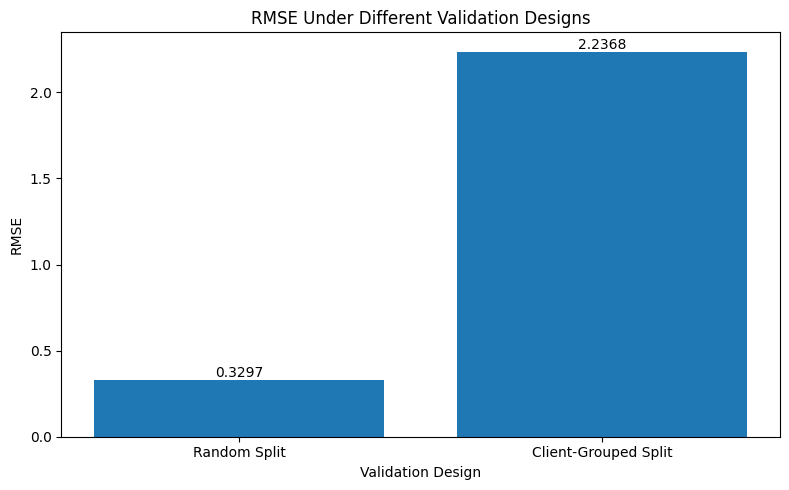


ARTIFACT 2 — RMSE COMPARISON
------------------------------


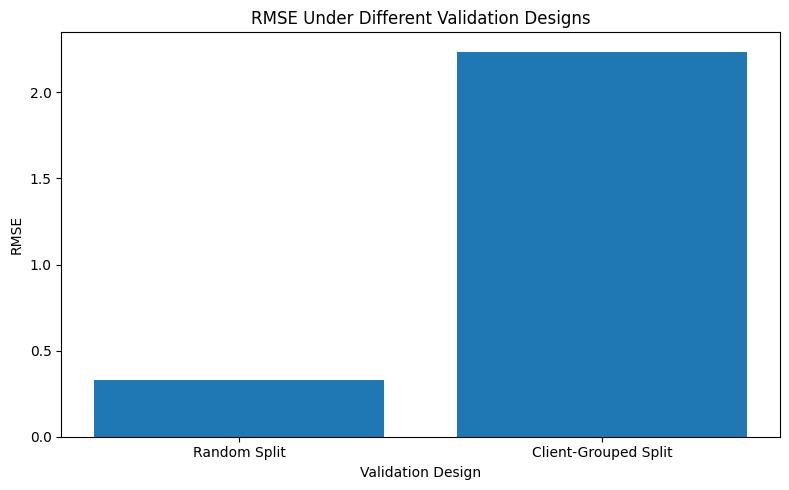


ARTIFACT 3 — MODEL / FEATURE EVIDENCE
------------------------------


,Feature,Signal_Type
0,gsc_impressions,Search visibility
1,gsc_avg_position,Search position
2,ga4_pageviews,Page engagement
3,ga4_sessions,Session engagement
4,ga4_users,User engagement
5,sessions_organic,Organic search engagement
6,scroll_events,Content engagement



ARTIFACT 4 — RECOMMENDATION FRAMEWORK
------------------------------


,Artifact,Purpose
0,Model-based review priorities,Identifies observations that may deserve conte...
1,Validation comparison,Shows how validation design affects measured m...
2,Feature/model evidence,Documents the measurable signals used by the R...
3,Limitations and interpretation,Defines the appropriate interpretation and bou...



PAPER ARTIFACTS
------------------------------

The final research paper should prioritize evidence that directly
supports the research question and the decision-support objective.

1. VALIDATION COMPARISON

The validation comparison shows that measured performance changes
under different validation designs.

Random Split:
- MAE: 0.1488
- RMSE: 0.3297
- R²: 0.7629

Client-Grouped Split:
- MAE: 0.3086
- RMSE: 2.2368
- R²: 0.1351

The client-grouped result is treated as the more conservative
validation estimate when discussing performance on unseen clients.

2. RANKED RECOMMENDATIONS

Section 6 produces model-based review priorities using the
Random Forest positive-class probability.

These priorities identify observations that may deserve review
based on measurable performance signals.

The ranking is a decision-support artifact.

It is not a guaranteed prediction of future performance.

3. MODEL / FEATURE EVIDENCE

The Random Forest uses seven measurable search and engagement
signals:

In [ ]:
# ============================================================
# CAPSTONE — SECTION 7: PAPER ARTIFACTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("SECTION 7 — PAPER ARTIFACTS")
print("=" * 60)

# ------------------------------------------------------------
# ARTIFACT 1 — RMSE VALIDATION COMPARISON
# ------------------------------------------------------------

print("\nARTIFACT 1 — RMSE VALIDATION COMPARISON")
print("-" * 30)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Validation"],
    results["RMSE"]
)

plt.title("RMSE Under Different Validation Designs")
plt.xlabel("Validation Design")
plt.ylabel("RMSE")

# Add exact RMSE values above each bar
for bar, value in zip(bars, results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ARTIFACT 2 — RMSE COMPARISON CHART
# ------------------------------------------------------------

print("\nARTIFACT 2 — RMSE COMPARISON")
print("-" * 30)

plt.figure(figsize=(8, 5))

plt.bar(
    results["Validation"],
    results["RMSE"]
)

plt.title("RMSE Under Different Validation Designs")
plt.xlabel("Validation Design")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ARTIFACT 3 — MODEL / FEATURE EVIDENCE
# ------------------------------------------------------------

print("\nARTIFACT 3 — MODEL / FEATURE EVIDENCE")
print("-" * 30)

feature_evidence = pd.DataFrame({
    "Feature": [
        "gsc_impressions",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "sessions_organic",
        "scroll_events"
    ],
    "Signal_Type": [
        "Search visibility",
        "Search position",
        "Page engagement",
        "Session engagement",
        "User engagement",
        "Organic search engagement",
        "Content engagement"
    ]
})

display(feature_evidence)

# ------------------------------------------------------------
# ARTIFACT 4 — RECOMMENDATION FRAMEWORK
# ------------------------------------------------------------

print("\nARTIFACT 4 — RECOMMENDATION FRAMEWORK")
print("-" * 30)

recommendation_artifact = pd.DataFrame({
    "Artifact": [
        "Model-based review priorities",
        "Validation comparison",
        "Feature/model evidence",
        "Limitations and interpretation"
    ],
    "Purpose": [
        "Identifies observations that may deserve content review.",
        "Shows how validation design affects measured model performance.",
        "Documents the measurable signals used by the Random Forest.",
        "Defines the appropriate interpretation and boundaries of the analysis."
    ]
})

display(recommendation_artifact)

# ------------------------------------------------------------
# PAPER ARTIFACT GUIDANCE
# ------------------------------------------------------------

print("""
PAPER ARTIFACTS
------------------------------

The final research paper should prioritize evidence that directly
supports the research question and the decision-support objective.

1. VALIDATION COMPARISON

The validation comparison shows that measured performance changes
under different validation designs.

Random Split:
- MAE: 0.1488
- RMSE: 0.3297
- R²: 0.7629

Client-Grouped Split:
- MAE: 0.3086
- RMSE: 2.2368
- R²: 0.1351

The client-grouped result is treated as the more conservative
validation estimate when discussing performance on unseen clients.

2. RANKED RECOMMENDATIONS

Section 6 produces model-based review priorities using the
Random Forest positive-class probability.

These priorities identify observations that may deserve review
based on measurable performance signals.

The ranking is a decision-support artifact.

It is not a guaranteed prediction of future performance.

3. MODEL / FEATURE EVIDENCE

The Random Forest uses seven measurable search and engagement
signals:

- gsc_impressions
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- sessions_organic
- scroll_events

The target-derived variable gsc_clicks is excluded from the
feature set because it is used to construct the target.

trend_direction and trend_pct are also excluded as leakage controls.

4. LIMITATIONS

The paper should clearly state that:

- The analysis uses anonymized internship data.
- The model does not reproduce Google's search-ranking algorithm.
- The analysis does not establish causation.
- Validation performance may differ on new clients or datasets.
- Recommendations should be interpreted as review priorities.

FINAL ARTIFACT PRINCIPLE
------------------------------

The paper should present evidence that answers:

"What did we measure?"

"How did validation design affect the measured result?"

"Which observations may deserve review first?"

"What limitations should the reader consider?"

The artifacts support transparent, measured, and directional
decision-support rather than guaranteed ranking outcomes.

Section 7 completed successfully.
""")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.